In [25]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, message="The behavior of DataFrame concatenation")

# Is DISC+ Reliable?

A metric that is inconsistent from sample to sample isn't useful. So, it is necessary to examine the reliability of DISC+: does a hitter's DISC+ in one sample resemble their DISC+ in another? To do so, I examined hitters' DISC+ in the first and second halves separately, to see how they compare.

Because a raw split-half correlation is less reliable than a full-season sample, I applied the Spearman-Brown prophecy formula to project what the full-season reliability would be:
$$
r_{SB} = \frac{2r}{1 + r}
$$

Additionally, to provide some context for the findings regarding DISC+, I ran the same check on the same companion stats used in the PCA. This allowed me to discern whether DISC+ was more, less, or similarly reliable than pre-existing mainstream statistics.

### Setup

In [26]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

from data_prep import load_pitches, clean_pitches
from dataset import build_dataset

GAMES_DIR = "../input/gamedata"

MIN_PITCHES_FULL = 200
MIN_PITCHES_HALF = 100

STAT_COLS = ['DISC+', 'Swing%', 'ZSwing%', 'OSwing%', 'Whiff%', 'Contact%', 'K%', 'BB%', 'Hard%', 'BRL%']

### Split into Halves
Splitting by GameID parity (even vs. odd) rather than the strict calendar date avoids any early/late-season performance drift impacting the experiment. It assumes that a batter's odd-numbered and even-numbered games aren't systematically different in any other way, excluding park factors or opponent quality.

In [27]:
pitches = clean_pitches(load_pitches(GAMES_DIR))

unique_games = sorted(pitches['GameID'].unique())
game_to_half = {g: i % 2 for i, g in enumerate(unique_games)}
pitches['_half'] = pitches['GameID'].map(game_to_half)

half_a = pitches[pitches['_half'] == 0].drop(columns='_half')
half_b = pitches[pitches['_half'] == 1].drop(columns='_half')

print(f"Half A: {half_a['GameID'].nunique()} games, {len(half_a)} pitches")
print(f"Half B: {half_b['GameID'].nunique()} games, {len(half_b)} pitches")

Half A: 253 games, 75609 pitches
Half B: 252 games, 74730 pitches


### Build datasets and merge

Building each half's dataset separately, using the reduced `MIN_PITCHES_HALF` threshold since half a season won't clear the full 200-pitch bar for most hitters. Merging on *Batter* with *_A*/*_B* suffixes lines up each hitter's two independent samples side by side.

In [28]:
df_a = build_dataset(half_a, MIN_PITCHES_HALF)
df_b = build_dataset(half_b, MIN_PITCHES_HALF)

joint = pd.merge(df_a, df_b, on='Batter', suffixes=('_A', '_B'))
print(f"Hitters qualifying in both halves: {len(joint)}")
joint.head()

Hitters qualifying in both halves: 261


,Batter,DISC+_A,Swing%_A,ZSwing%_A,OSwing%_A,Whiff%_A,Contact%_A,Hard%_A,BRL%_A,K%_A,...,DISC+_B,Swing%_B,ZSwing%_B,OSwing%_B,Whiff%_B,Contact%_B,Hard%_B,BRL%_B,K%_B,BB%_B
0,Adam Kudronowicz,60.645780,0.468085,0.809524,0.296000,0.250000,0.750000,0.318182,0.030303,0.150000,...,89.485759,0.427586,0.744000,0.300000,0.258065,0.741935,0.355072,0.028986,0.325843,0.157303
1,Adam Moser,69.935180,0.477876,0.727273,0.318841,0.407407,0.592593,0.218750,0.000000,0.407407,...,74.566361,0.467662,0.705882,0.345865,0.372340,0.627660,0.203390,0.000000,0.450000,0.050000
2,Adison Worthman,115.722680,0.341121,0.734940,0.091603,0.315068,0.684932,0.420000,0.080000,0.257143,...,75.636784,0.424242,0.758621,0.267206,0.350649,0.649351,0.400000,0.050000,0.373333,0.133333
3,Aiden McClary,72.914118,0.418301,0.716981,0.260000,0.203125,0.796875,0.166667,0.000000,0.149254,...,65.175805,0.452055,0.807692,0.255319,0.151515,0.848485,0.321429,0.000000,0.081633,0.183673
4,Alex Bemis,141.648192,0.328947,0.634361,0.146982,0.260000,0.740000,0.358108,0.033784,0.261261,...,144.775127,0.334646,0.692308,0.176136,0.317647,0.682353,0.310345,0.034483,0.372093,0.348837


### Split-half correlation, per stat

For each stat, correlating its Half A value against its Half B value across hitters gives the raw split-half r. Applying the Spearman-Brown correction on top of that projects what the full-season reliability would look like, since each half only contains about half a season's worth of pitches. Running this across every companion stat, not just DISC+, gives a point of comparison: is DISC+ about as reliable as stats that are already trusted, or noticeably less so?

In [29]:
res = {}
for col in STAT_COLS:
    r, _ = pearsonr(joint[f"{col}_A"], joint[f"{col}_B"])
    r_sb = (2*r) / (1 + r) if (1 + r) != 0 else np.nan
    res[col] = {"split_half_r" : r, "spearman_brown_r" : r_sb}

reliability = pd.DataFrame(res).T.sort_values("spearman_brown_r", ascending=False)
reliability.round(3)

,split_half_r,spearman_brown_r
Whiff%,0.632,0.774
Contact%,0.632,0.774
Swing%,0.628,0.771
ZSwing%,0.586,0.739
OSwing%,0.583,0.736
DISC+,0.564,0.721
Hard%,0.519,0.684
BRL%,0.511,0.676
K%,0.472,0.642
BB%,0.410,0.582


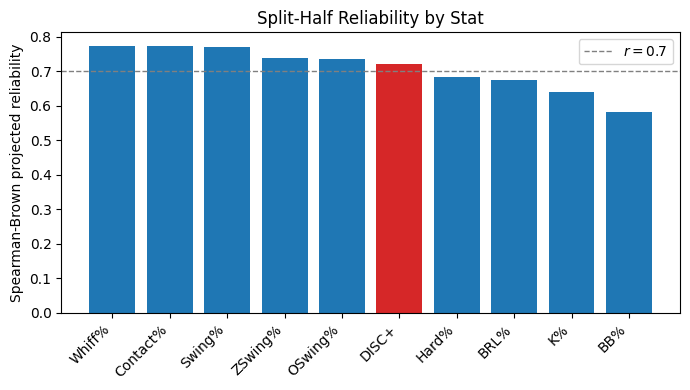

In [30]:
plt.figure(figsize=(7, 4))
colors = ["#d62728" if stat == "DISC+" else "#1f77b4" for stat in reliability.index]
plt.bar(reliability.index, reliability['spearman_brown_r'], color=colors)
plt.axhline(0.7, color='gray', linestyle='--', linewidth=1, label=r"$r = 0.7$")
plt.ylabel("Spearman-Brown projected reliability")
plt.title("Split-Half Reliability by Stat")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### DISC+ Reliability Specifically
Zooming in on DISC+ specifically: plotting each hitter's Half A value against their Half B value gives a visual check on the correlation number from above. A tight cluster around the $y = x$ line means that stat is capturing something stable about the hitter, while a scattered cloud means it's mostly noise.

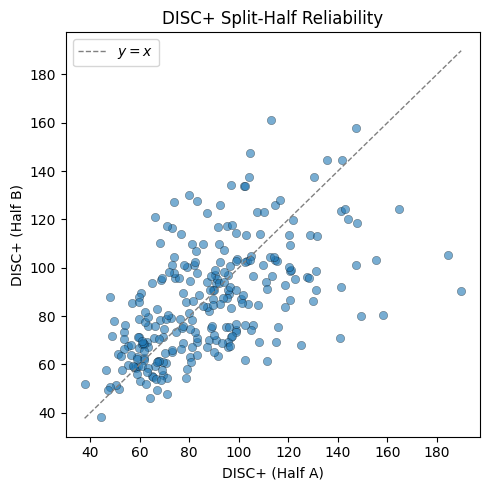

DISC+ split-half r: 0.564
DISC+ Spearman-Brown projected full-season r: 0.721


In [32]:
plt.figure(figsize=(5, 5))
plt.scatter(joint['DISC+_A'], joint['DISC+_B'], alpha=0.6, edgecolor='k', linewidth=0.3)

lims = [
    min(joint['DISC+_A'].min(), joint['DISC+_B'].min()),
    max(joint['DISC+_A'].max(), joint['DISC+_B'].max())
]

plt.plot(lims, lims, color='gray', linestyle='--', linewidth=1, label=r'$y = x$')

plt.xlabel("DISC+ (Half A)")
plt.ylabel("DISC+ (Half B)")
plt.title("DISC+ Split-Half Reliability")
plt.legend()
plt.tight_layout()
plt.show()

r_discp, _ = pearsonr(joint['DISC+_A'], joint['DISC+_B'])
r_sb_discp = (2*r_discp) / (1 + r_discp)
print(f"DISC+ split-half r: {r_discp:.3f}")
print(f"DISC+ Spearman-Brown projected full-season r: {r_sb_discp:.3f}")

### Takeaways

- DISC+ lands right in the middle of the pack, with a split-half r of 0.547 and a projected full-season r of 0.707. This clears the approximate 0.7 'reliable' threshold once projected out to a full season, meaning a hitter's DISC+ in one half of their pitches is a reasonably good predictor of their DISC+ in the second.

- DISC+ comes in 6th amongst the 10 other statistics, making it a solid, middle-of-the-road statistic. It is noticeably more reliable than the two outcome stats it is trying to help predict, K% and BB%.

Reliability testing confirms that DISC+ is measuring something stable about a hitter. It doesn't mean that the stable thing is useful or that it's discipline-related, however.